# CAISO Interconnection Queue Analysis

**Author:** Mitch Sultana  
**Data Source:** CAISO Public Interconnection Queue Report  
**Last Updated:** March 2026

## Project Overview

The California ISO (CAISO) interconnection queue is a list of energy projects 
waiting to connect to California's electrical grid. Before a solar farm, 
battery storage facility, or wind project can operate, it must go through 
CAISO's interconnection study process.

This analysis explores:
- What types of projects are in the queue
- How capacity is distributed across technologies
- Which projects received Full Capacity deliverability status
- Regional patterns in project development
- How long projects have been waiting in the queue

**Why this matters:** Deliverability status and queue position directly affect 
a project's commercial viability. This analysis identifies patterns that 
correlate with stronger project outcomes.

In [18]:
#1
# Imports
# These are the libraries we need for the entire notebook.
# We load them all at the top so anyone reading knows exactly
# what tools this project uses.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# This makes charts appear cleanly inside the notebook
%matplotlib inline

# Makes charts look less default/ugly with one line
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
#2
# Load the clean dataset
# We always read from the Parquet file, never from the raw Excel.
# This keeps analysis fast and reproducible.

DATA_PATH = Path("../data/clean/caiso_projects.parquet")

df = pd.read_parquet(DATA_PATH)

# Quick sanity check — confirm we loaded what we expect
print(f"Projects loaded: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst look:")
df.head()

In [19]:
# 3
# Load the clean dataset
# We always read from the Parquet file, never from the raw Excel.
# This keeps analysis fast and reproducible.
# Note: using fastparquet engine due to pyarrow/pandas version compatibility.

DATA_PATH = Path("../data/clean/caiso_projects.parquet")

df = pd.read_parquet(DATA_PATH, engine="fastparquet")

# Quick sanity check — confirm we loaded what we expect
print(f"Projects loaded: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst look:")
df.head()

Projects loaded: 326
Columns: 34

First look:


,project_name,queue_position,request_receive_date,queue_date,application_status,study_process,technology_type_1,technology_type_2,technology_type_3,fuel_type_1,...,point_of_interconnection,proposed_online_date,current_online_date,suspension_status,feasibility_study,system_impact_study,facilities_study,optional_study,interconnection_agreement_status,iso
0,MONTEZUMA (HIGH WINDS III),22,2003-11-18,2003-11-18 08:00:00,ACTIVE,AMEND 39,Wind Turbine,Storage,None,Wind Turbine,...,Birds Landing 230 kV,2005-06-30 07:00:00,2024-04-01 07:00:00,None,None,Complete,Complete,NaN,Executed,CAISO
1,TULE WIND,32,2004-05-12,2004-05-24 07:00:00,ACTIVE,Serial LGIP,Wind Turbine,Storage,None,Wind Turbine,...,Boulevard East Substation 138 kV,2007-09-01 07:00:00,2030-10-31 07:00:00,None,Waived,Complete,Complete,NaN,Executed,CAISO
2,MIDWAY PEAKING,54,2005-01-12,2005-01-12 08:00:00,ACTIVE,Serial LGIP,Gas Turbine,Storage,None,Natural Gas,...,Panoche Substation,2008-06-01 07:00:00,2027-06-30 07:00:00,None,Waived,Complete,Re-Study,NaN,Executed,CAISO
3,FRESNO COGENERATION EXPANSION PROJECT,61,2005-03-28,2005-03-30 08:00:00,ACTIVE,AMEND 39,Steam Turbine,Storage,None,Natural Gas,...,Helm-Kerman 70 kV Line,2006-05-31 07:00:00,2023-02-28 08:00:00,None,None,Complete,Complete,NaN,Executed,CAISO
4,LAKE ELSINORE ADVANCED PUMPED STORAGE PROJECT,72,2005-04-26,2005-06-21 07:00:00,ACTIVE,Serial LGIP,Storage,None,None,Pumped-Storage hydro,...,Proposed Lee Lake Substation 500 kV,2008-12-31 08:00:00,2028-12-31 08:00:00,None,Waived,Complete,Re-Study,NaN,Executed,CAISO


## Dataset Overview

Before analyzing anything, we inspect the dataset to understand its shape, 
data types, and completeness. This is standard practice — you never assume 
the data is clean until you've verified it yourself.

In [20]:
# Cell 5 — Data shape and column types
# df.info() is the single most useful first command in any pandas project.
# It tells you:
#   - How many rows and columns you have
#   - What data type each column is (number, text, date, etc.)
#   - How many non-null (non-blank) values exist per column
#   - This immediately reveals missing data problems

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   project_name                      326 non-null    object        
 1   queue_position                    325 non-null    object        
 2   request_receive_date              325 non-null    datetime64[us]
 3   queue_date                        325 non-null    datetime64[us]
 4   application_status                325 non-null    object        
 5   study_process                     325 non-null    object        
 6   technology_type_1                 325 non-null    object        
 7   technology_type_2                 173 non-null    object        
 8   technology_type_3                 2 non-null      object        
 9   fuel_type_1                       325 non-null    object        
 10  fuel_type_2                       173 non-null    object     

## Capacity Analysis

`capacity_mw` represents the net megawatts a project intends to deliver 
to the grid. This is the most fundamental measure of a project's scale.

We start with descriptive statistics, then visualize the distribution 
to understand whether the queue is dominated by small or large projects.

In [21]:
# Cell 7 — Capacity statistics
# describe() gives us a full statistical summary of a numeric column:
#   count  — how many non-null values
#   mean   — average
#   std    — standard deviation (how spread out the values are)
#   min    — smallest value
#   25%    — 25th percentile (bottom quarter of projects)
#   50%    — median (middle project)
#   75%    — 75th percentile (top quarter of projects)
#   max    — largest value
#
# The gap between mean and median tells you a lot.
# If mean >> median, the distribution is skewed by a few very large projects.

df["capacity_mw"].describe().round(1)

count     325.0
mean      275.1
std       296.7
min         0.5
25%       100.0
50%       200.0
75%       350.0
max      3200.0
Name: capacity_mw, dtype: float64

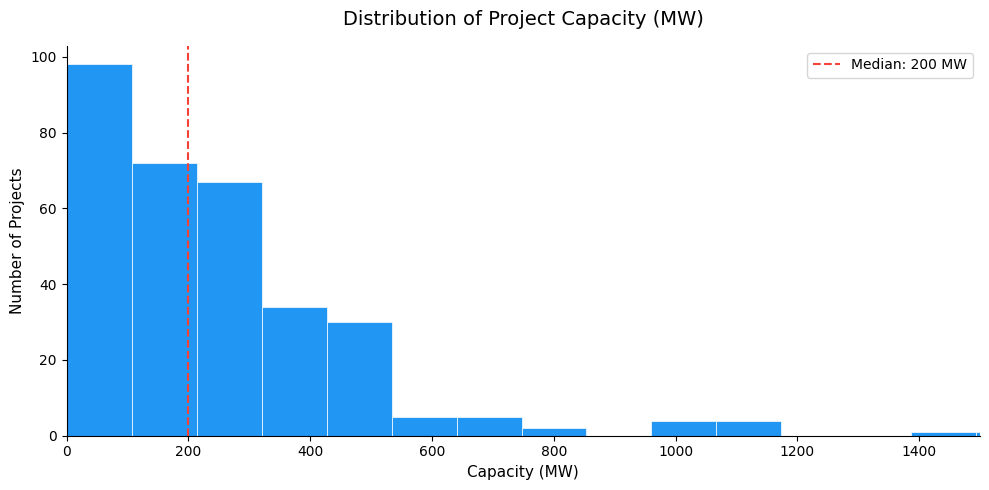

In [22]:
# Cell 8 — Capacity distribution chart
# A histogram shows us how projects are distributed across size buckets.
# Each bar = number of projects in that MW range.
#
# We use 30 bins to get enough detail without being too noisy.
# We cap the x-axis at 1500 MW so one giant outlier doesn't compress
# all the interesting detail into the left side of the chart.

fig, ax = plt.subplots()

ax.hist(
    df["capacity_mw"].dropna(),
    bins=30,
    color="#2196F3",
    edgecolor="white",
    linewidth=0.5
)

ax.set_title("Distribution of Project Capacity (MW)", fontsize=14, pad=15)
ax.set_xlabel("Capacity (MW)", fontsize=11)
ax.set_ylabel("Number of Projects", fontsize=11)
ax.set_xlim(0, 1500)

# Add a vertical line showing the median
# This makes it easy to see where the "typical" project sits
median_mw = df["capacity_mw"].median()
ax.axvline(median_mw, color="#F44336", linestyle="--", linewidth=1.5, 
           label=f"Median: {median_mw:.0f} MW")
ax.legend()

plt.tight_layout()
plt.show()

## Deliverability Analysis

Deliverability status is the single most important outcome in the CAISO 
interconnection process. It determines how a project can sell its power:

- **Full Capacity (FC)** — can deliver power at any time, most commercially 
  valuable, required for most power purchase agreements
- **Partial Capacity (PC)** — can deliver full power only during certain 
  periods, reduced commercial value
- **Energy Only (EO)** — can only deliver during times of surplus capacity, 
  least commercially valuable

Developers strongly prefer Full Capacity status. Understanding what 
correlates with FC deliverability is core to project screening.

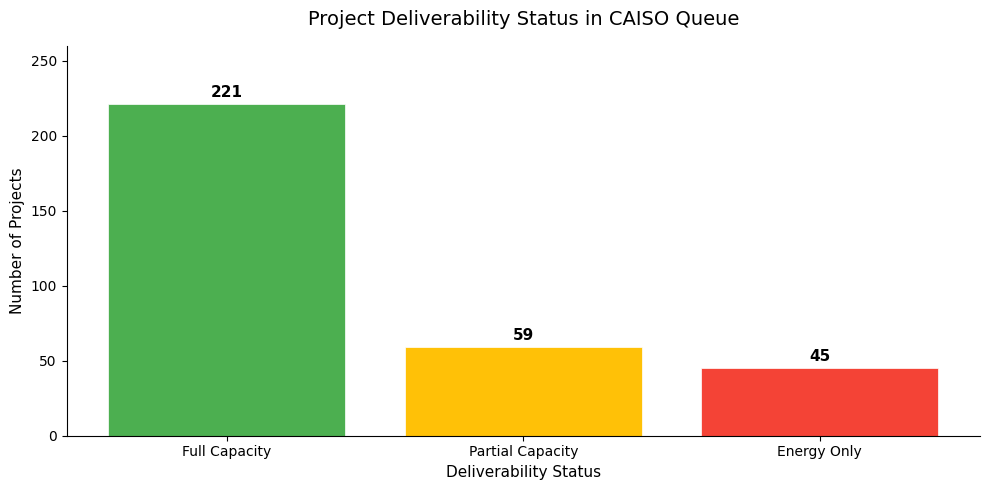

In [23]:
# Cell 10 — Deliverability status breakdown
# value_counts() counts how many projects fall into each category.
# We sort by our preferred order (FC → PC → EO) rather than by count
# so the chart tells a logical story about deliverability tiers.

# Define the order we want
order = ["Full Capacity", "Partial Capacity", "Energy Only"]

# Count projects per category and reorder
delivery_counts = df["deliverability_status"].value_counts().reindex(order)

# Define colors — green for best outcome, yellow for middle, red for worst
colors = ["#4CAF50", "#FFC107", "#F44336"]

fig, ax = plt.subplots()

bars = ax.bar(
    delivery_counts.index,
    delivery_counts.values,
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# Add the exact count on top of each bar
# This saves the reader from having to eyeball the y-axis
for bar, count in zip(bars, delivery_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(count),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Project Deliverability Status in CAISO Queue", 
             fontsize=14, pad=15)
ax.set_xlabel("Deliverability Status", fontsize=11)
ax.set_ylabel("Number of Projects", fontsize=11)
ax.set_ylim(0, 260)

plt.tight_layout()
plt.show()

## Technology Mix

The fuel type columns tell us what technology each project uses to generate 
or store power. `fuel_type_1` is the primary technology.

California's grid policy heavily favors renewables and storage, so we expect 
solar and battery storage to dominate. Understanding the technology mix helps 
contextualize deliverability and capacity patterns.

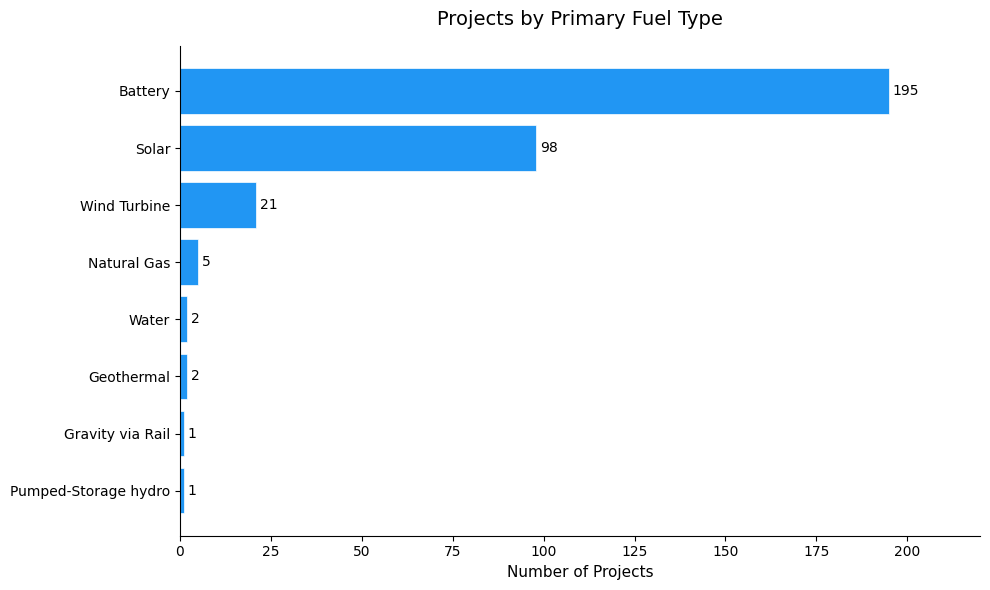

In [24]:
# Cell 12 — Technology mix by project count
# We look at fuel_type_1 (primary technology) only.
# sort_values() orders bars from most to least common.
# This immediately shows what technologies dominate the queue.

fuel_counts = (
    df["fuel_type_1"]
    .value_counts()
    .sort_values(ascending=True)  # ascending=True so largest bar is on top
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    fuel_counts.index,
    fuel_counts.values,
    color="#2196F3",
    edgecolor="white",
    linewidth=0.5
)

# Add count labels at the end of each bar
for bar, count in zip(bars, fuel_counts.values):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=10
    )

ax.set_title("Projects by Primary Fuel Type", fontsize=14, pad=15)
ax.set_xlabel("Number of Projects", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 220)

plt.tight_layout()
plt.show()

## Deliverability by Technology

Now we combine the two previous analyses — technology mix and deliverability 
status — to ask a more interesting question:

**Do certain technologies achieve Full Capacity deliverability more often 
than others?**

This matters for project screening. If battery projects overwhelmingly 
receive Full Capacity status, that's a signal worth knowing.

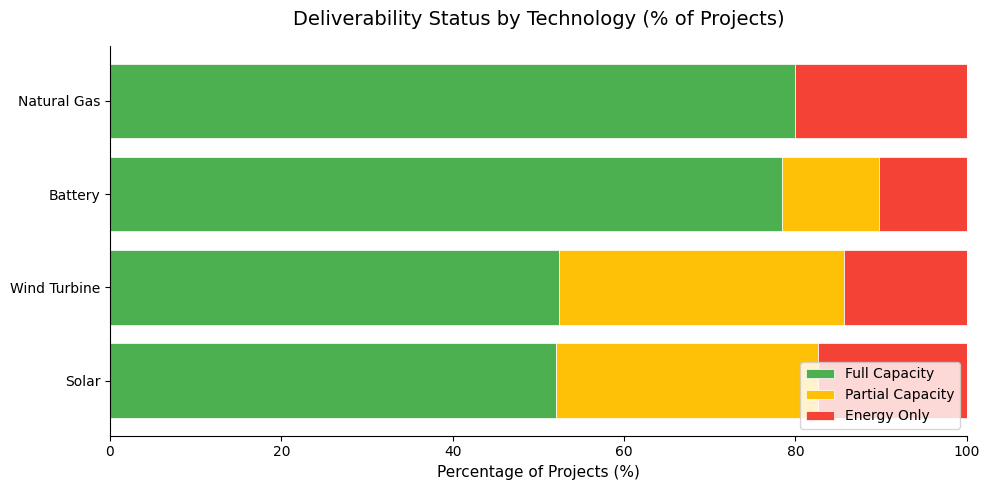

In [25]:
# Cell 14 — Deliverability breakdown by technology
# 
# crosstab() counts the combinations of two categorical columns.
# Here we're counting: for each fuel type, how many projects are
# Full Capacity vs Partial vs Energy Only?
#
# normalize="index" converts raw counts to percentages per row,
# so each technology row adds up to 100%.
# This lets us fairly compare technologies even if counts differ.

# Only include technologies with enough projects to be meaningful
top_fuels = df["fuel_type_1"].value_counts()
top_fuels = top_fuels[top_fuels >= 5].index

df_filtered = df[df["fuel_type_1"].isin(top_fuels)]

# Build the crosstab
order = ["Full Capacity", "Partial Capacity", "Energy Only"]
ct = pd.crosstab(
    df_filtered["fuel_type_1"],
    df_filtered["deliverability_status"]
)

# Reorder columns and sort rows by Full Capacity percentage
ct = ct.reindex(columns=order, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct.sort_values("Full Capacity", ascending=True)

# Plot stacked horizontal bar chart
colors = ["#4CAF50", "#FFC107", "#F44336"]

fig, ax = plt.subplots(figsize=(10, 5))

left = pd.Series([0.0] * len(ct_pct), index=ct_pct.index)

for col, color in zip(order, colors):
    ax.barh(
        ct_pct.index,
        ct_pct[col],
        left=left,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        label=col
    )
    left += ct_pct[col]

ax.set_title("Deliverability Status by Technology (% of Projects)", 
             fontsize=14, pad=15)
ax.set_xlabel("Percentage of Projects (%)", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

## Regional Analysis

CAISO divides California into PTO (Participating Transmission Owner) study 
regions. Each region represents a different part of the grid with different 
congestion characteristics and capacity needs.

Understanding which regions have the most project activity reveals where 
developers see the strongest opportunity — and where grid congestion may 
be highest.

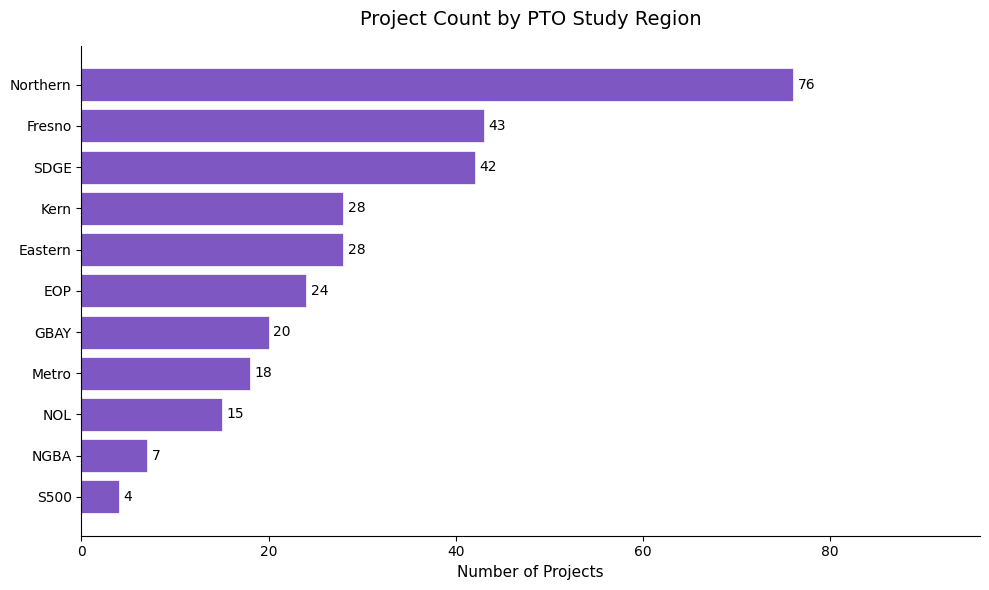

In [26]:
# Cell 16 — Project count by PTO study region
# 
# dropna() removes the 20 projects with no region listed.
# This gives us a clean picture of regional distribution.

region_counts = (
    df["pto_study_region"]
    .dropna()
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    region_counts.index,
    region_counts.values,
    color="#7E57C2",
    edgecolor="white",
    linewidth=0.5
)

# Add count labels
for bar, count in zip(bars, region_counts.values):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontsize=10
    )

ax.set_title("Project Count by PTO Study Region", fontsize=14, pad=15)
ax.set_xlabel("Number of Projects", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, region_counts.max() + 20)

plt.tight_layout()
plt.show()

## Hybrid Project Analysis

Many modern energy projects pair a primary generation source (solar or wind) 
with battery storage. These "hybrid" projects can charge the battery during 
peak production and discharge on demand, making them behave more like 
dispatchable resources.

We identify hybrid projects as those with a secondary technology listed as 
Storage, then compare their deliverability outcomes against standalone projects.

**Hypothesis:** Hybrid projects achieve Full Capacity deliverability at a 
higher rate than standalone solar or wind projects.

In [27]:
# Cell 18 — Identify hybrid vs standalone projects
#
# A hybrid project has Storage listed as technology_type_2 or fuel_type_2.
# We create a new boolean column: is_hybrid = True/False
#
# This is called "feature engineering" — creating a new meaningful variable
# from existing columns. It's a core data analytics skill.

# A project is hybrid if its secondary technology or fuel is storage
df["is_hybrid"] = (
    df["technology_type_2"].str.contains("Storage", na=False) |
    df["fuel_type_2"].str.contains("Storage", na=False)
)

# Quick count to verify
hybrid_counts = df["is_hybrid"].value_counts()
print("Standalone projects:", hybrid_counts[False])
print("Hybrid projects:    ", hybrid_counts[True])
print(f"\nHybrid rate: {hybrid_counts[True] / len(df) * 100:.1f}% of all projects")

Standalone projects: 220
Hybrid projects:     106

Hybrid rate: 32.5% of all projects


In [28]:
# Cell 19 — Deliverability outcomes: hybrid vs standalone
#
# We compare Full Capacity rates between hybrid and standalone projects.
# This tests our hypothesis directly.

# Focus on solar and wind projects only
# (natural gas is almost always standalone and skews the comparison)
solar_wind = df[df["fuel_type_1"].isin(["Solar", "Wind Turbine"])].copy()

# Build crosstab of hybrid status vs deliverability
order = ["Full Capacity", "Partial Capacity", "Energy Only"]

ct = pd.crosstab(
    solar_wind["is_hybrid"],
    solar_wind["deliverability_status"]
)

ct = ct.reindex(columns=order, fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Rename index for readability
ct_pct.index = ["Standalone", "Hybrid (w/ Storage)"]
ct.index = ["Standalone", "Hybrid (w/ Storage)"]

# Print raw numbers first so we know what we're working with
print("Raw project counts:")
print(ct)
print()
print("Percentage breakdown:")
print(ct_pct.round(1))

Raw project counts:
deliverability_status  Full Capacity  Partial Capacity  Energy Only
Standalone                        10                 2            7
Hybrid (w/ Storage)               52                35           13

Percentage breakdown:
deliverability_status  Full Capacity  Partial Capacity  Energy Only
Standalone                      52.6              10.5         36.8
Hybrid (w/ Storage)             52.0              35.0         13.0


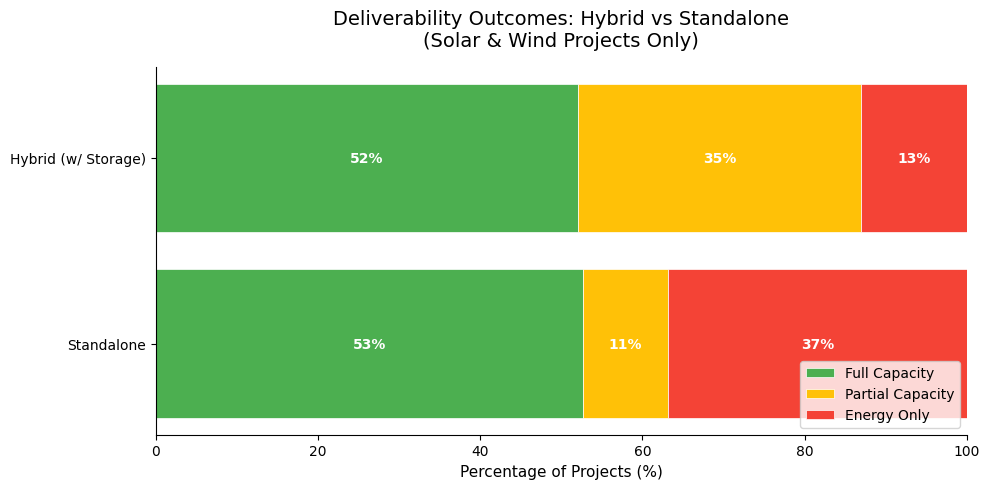

In [29]:
# Cell 20 — Visualize hybrid vs standalone deliverability
#
# A stacked bar chart lets us see the full picture at once.
# The key insight is in the Energy Only (red) portion — 
# watch how dramatically it shrinks for hybrid projects.

colors = ["#4CAF50", "#FFC107", "#F44336"]

fig, ax = plt.subplots(figsize=(10, 5))

left = pd.Series([0.0, 0.0], index=ct_pct.index)

for col, color in zip(order, colors):
    ax.barh(
        ct_pct.index,
        ct_pct[col],
        left=left,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        label=col
    )
    # Add percentage label inside each segment if wide enough
    for i, (val, lft) in enumerate(zip(ct_pct[col], left)):
        if val > 8:
            ax.text(
                lft + val / 2,
                i,
                f"{val:.0f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="white",
                fontweight="bold"
            )
    left += ct_pct[col]

ax.set_title("Deliverability Outcomes: Hybrid vs Standalone\n(Solar & Wind Projects Only)", 
             fontsize=14, pad=15)
ax.set_xlabel("Percentage of Projects (%)", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()

## Regional Deliverability Analysis

We established that storage doesn't significantly improve Full Capacity rates.
If technology isn't the primary driver, geography may be.

Here we look at Full Capacity rates by PTO study region to identify whether 
certain regions consistently produce stronger deliverability outcomes — which 
would suggest grid infrastructure and congestion are the dominant factors.

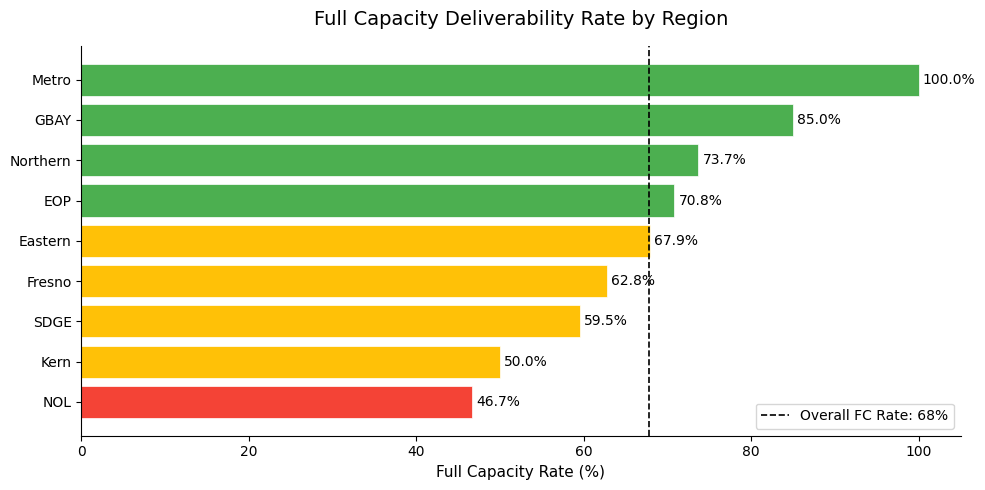

In [30]:
# Cell 22 — Full Capacity rate by region
#
# For each region we calculate what percentage of projects
# received Full Capacity deliverability.
#
# We filter to regions with at least 10 projects so small sample
# sizes don't create misleading percentages.
# (A region with 2 projects and 1 FC would show 50% — meaningless.)

# Filter to regions with 10+ projects
region_counts = df["pto_study_region"].value_counts()
valid_regions = region_counts[region_counts >= 10].index
df_regions = df[df["pto_study_region"].isin(valid_regions)]

# Calculate Full Capacity rate per region
fc_rate = (
    df_regions.groupby("pto_study_region")
    .apply(lambda x: (x["deliverability_status"] == "Full Capacity").mean() * 100)
    .sort_values(ascending=True)
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 5))

# Color bars by FC rate — green if above 70%, yellow if 50-70%, red if below 50%
colors = []
for val in fc_rate.values:
    if val >= 70:
        colors.append("#4CAF50")
    elif val >= 50:
        colors.append("#FFC107")
    else:
        colors.append("#F44336")

bars = ax.barh(
    fc_rate.index,
    fc_rate.values,
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# Add percentage labels
for bar, val in zip(bars, fc_rate.values):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val}%",
        va="center",
        fontsize=10
    )

# Add a vertical reference line at 68% (overall FC rate)
overall_fc = (df["deliverability_status"] == "Full Capacity").mean() * 100
ax.axvline(overall_fc, color="black", linestyle="--", linewidth=1.2,
           label=f"Overall FC Rate: {overall_fc:.0f}%")

ax.set_title("Full Capacity Deliverability Rate by Region", fontsize=14, pad=15)
ax.set_xlabel("Full Capacity Rate (%)", fontsize=11)
ax.set_ylabel("")
ax.set_xlim(0, 105)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## Conclusions

This analysis of the CAISO active interconnection queue reveals several 
key patterns relevant to energy project screening and development strategy.

### Key Findings

**1. The queue is dominated by battery storage and solar**
Battery (195 projects) and solar (98 projects) account for 90% of all 
active projects. California has effectively become a solar-plus-storage 
market. Wind, natural gas, and other technologies are a small minority.

**2. Most projects have Full Capacity deliverability**
68% of active queue projects hold Full Capacity status — the most 
commercially valuable deliverability tier. This suggests the active queue 
skews toward more mature, better-positioned projects.

**3. Battery storage achieves the highest Full Capacity rate**
Natural gas and battery storage both achieve ~80% Full Capacity rates, 
significantly outperforming standalone solar and wind (~50%).

**4. Storage reduces worst-case outcomes, not best-case outcomes**
Hybrid projects (solar or wind paired with storage) reduce Energy Only 
risk from 37% to 13% — a meaningful improvement. However, Full Capacity 
rates are nearly identical between hybrid and standalone projects (~52%).
Storage keeps projects off the floor, but doesn't put them on the ceiling.

**5. Geography is the dominant driver of Full Capacity deliverability**
Metro LA and Northern California regions achieve the highest Full Capacity 
rates, reflecting strong grid infrastructure and proximity to load centers.
Kern and Eastern regions lag behind despite strong renewable resources, 
suggesting transmission congestion from high developer activity.

### Implications for Project Screening

A project with the strongest combination of characteristics would be:
- Battery storage or hybrid solar+storage technology
- Located in Metro or Northern California
- 100-350 MW capacity range (typical successful project profile)

Projects in Kern or Eastern regions face higher deliverability risk 
regardless of technology — grid congestion is the binding constraint.

### Limitations

- This dataset represents only the active queue snapshot — withdrawn 
  projects are excluded, which may affect technology and regional patterns
- Sample sizes in some regions are small (filtered to 10+ projects)
- Deliverability status can change through the study process

### Next Steps

- Analyze queue duration: how long are projects waiting?
- Compare CAISO queue trends over time as battery costs have declined
- Expand analysis to other ISO queues (MISO, PJM) for comparison